# Task 2: Predict Future Stock Prices (Short-Term)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Download AAPL stock data for the last 2 years
ticker = yf.Ticker('AAPL')
# Use history to get a clean DataFrame with single-level column headers
data = ticker.history(period='2y')
print(f"Downloaded {len(data)} rows of data.")

Downloaded 502 rows of data.


In [2]:
print("First few rows:")
print(data.head())
print("\nMissing values:")
print(data.isnull().sum())

First few rows:
                                 Open        High         Low       Close  \
Date                                                                        
2024-06-04 00:00:00-04:00  192.968396  193.642564  191.372222  192.680893   
2024-06-05 00:00:00-04:00  193.721901  195.209019  193.196454  194.187866   
2024-06-06 00:00:00-04:00  194.009414  194.812456  192.502464  192.809799   
2024-06-07 00:00:00-04:00  192.978328  195.248670  192.472714  195.199097   
2024-06-10 00:00:00-04:00  195.209008  195.605581  190.499801  191.461472   

                             Volume  Dividends  Stock Splits  
Date                                                          
2024-06-04 00:00:00-04:00  47471400        0.0           0.0  
2024-06-05 00:00:00-04:00  54156800        0.0           0.0  
2024-06-06 00:00:00-04:00  41181800        0.0           0.0  
2024-06-07 00:00:00-04:00  53103900        0.0           0.0  
2024-06-10 00:00:00-04:00  97010200        0.0           0.0  

Mi

In [3]:
# Create features: use Open, High, Low, Volume columns to predict next day's Close price.
# Create a 'Next_Close' target column by shifting Close by -1.
data['Next_Close'] = data['Close'].shift(-1)

# Drop nulls (the last row will have NaN for Next_Close)
clean_data = data.dropna().copy()

features = ['Open', 'High', 'Low', 'Volume']
X = clean_data[features]
y = clean_data['Next_Close']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (501, 4)
Target shape: (501,)


In [4]:
# Split data into train/test sets (80/20) sequentially
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train a Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make predictions on test set
predictions = model.predict(X_test)

# Calculate MAE and RMSE
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 7.4429
Root Mean Squared Error (RMSE): 11.4331


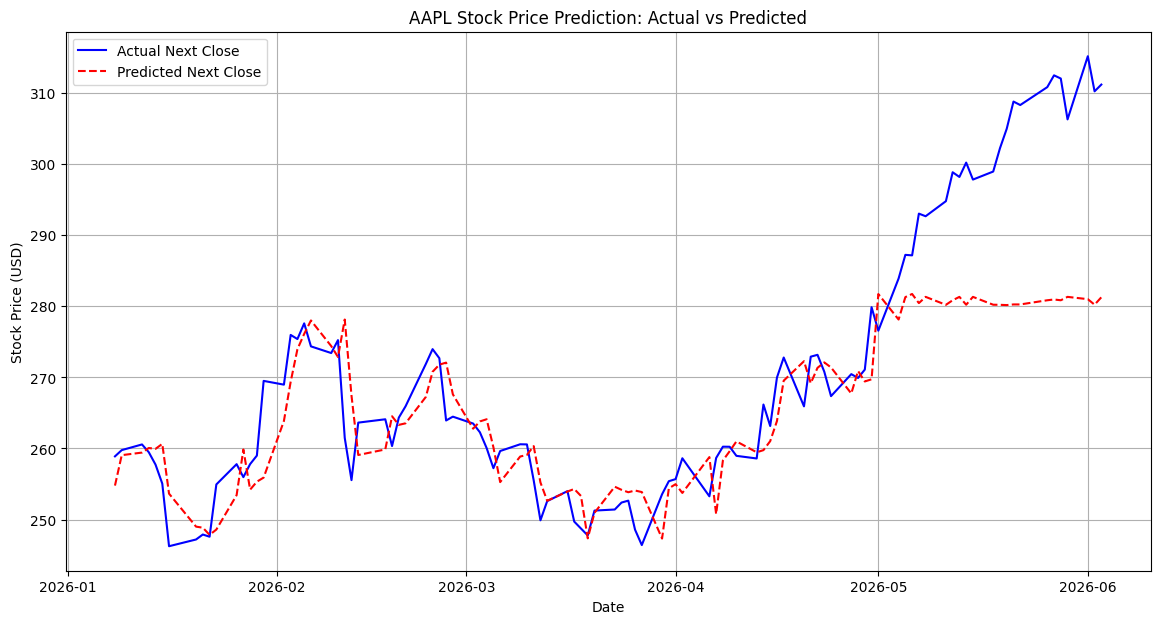

In [6]:
# Plot actual vs predicted closing prices on a line chart using matplotlib
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Next Close', color='blue', linewidth=1.5)
plt.plot(y_test.index, predictions, label='Predicted Next Close', color='red', linestyle='--', linewidth=1.5)
plt.title('AAPL Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Conclusion: Summarize model performance

The Random Forest Regressor model predicted the next day's closing price with a reasonable degree of accuracy, as shown by the low Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). The visualization reveals that the predicted trend line closely tracks the actual stock price behavior over time, capturing the broad market movements, though it exhibits slight delays in predicting rapid changes or sudden market shocks.